# Etapa 2 — Análise Exploratória (EDA)

Usamos o dataset já tratado na Etapa 1. Neste notebook fazemos as estatísticas descritivas, a matriz de correlação (Pearson e Spearman), os histogramas e os boxplots das variáveis numéricas.

In [1]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Carregamento dos dados

Lemos o CSV gerado na Etapa 1 (já limpo e com as variáveis numéricas padronizadas).

In [3]:
csv_path = _root / 'notebooks' / 'data' / 'processed' / 'restaurants_preprocessed.csv'
df = pd.read_csv(csv_path)

print(f"{df.shape[0]:,} restaurantes × {df.shape[1]} colunas")
df.head()

394,192 restaurantes × 8 colunas


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.659290,-1.251447,-0.562502,-1.094339
1,Açaí,CHEAPEST,0,5300108,0.292185,0.921866,-0.562502,-1.094339
2,Bebidas,MODERATE,0,5300108,1.243660,1.497155,-1.230091,-1.094339
3,Carnes,CHEAPEST,0,5300108,2.314070,1.049708,0.772676,-1.094339
4,Brasileira,CHEAPEST,0,5300108,1.243660,0.730104,0.772676,-1.094339


In [4]:
col_num = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating']
col_cat = ['category', 'price_range', 'availableForScheduling']

## 1. Estatísticas descritivas

As variáveis numéricas já vêm padronizadas da Etapa 1 (StandardScaler), então a média fica próxima de 0 e o desvio próximo de 1. O `describe()` mostra a dispersão relativa de cada uma.

In [5]:
df[col_num].describe()

,delivery_fee,delivery_time,minimumOrderValue,rating
count,3.941920e+05,3.941920e+05,3.941920e+05,3.941920e+05
mean,7.996021e-17,7.051496e-17,2.884047e-17,6.510737e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.608387e+00,-2.849472e+00,-1.897679e+00,-1.094339e+00
25%,-6.569116e-01,-7.400791e-01,-5.625019e-01,-1.094339e+00
50%,-1.811740e-01,-1.008693e-01,1.050868e-01,6.136197e-01
75%,6.489881e-01,8.579455e-01,7.726755e-01,9.668191e-01
max,2.554317e+00,3.223022e+00,2.775442e+00,1.090260e+00


In [6]:
print("Top 10 categorias:")
print(df['category'].value_counts().head(10))
print()
print("Faixa de preço:")
print(df['price_range'].value_counts())
print()
print(f"Com agendamento disponível: {df['availableForScheduling'].mean() * 100:.1f}%")
print(f"Municípios distintos (ibge): {df['ibge'].nunique():,}")

Top 10 categorias:
category
Lanches          97395
Brasileira       72032
Doces & Bolos    38916
Pizza            34666
Açaí             21924
Marmita          16389
Bebidas          12616
Japonesa         12539
Saudável          9562
Salgados          9478
Name: count, dtype: int64

Faixa de preço:
price_range
CHEAPEST          287603
MODERATE           42996
CHEAP              42235
EXPENSIVE          14294
MOST_EXPENSIVE      7064
Name: count, dtype: int64

Com agendamento disponível: 0.4%
Municípios distintos (ibge): 1,448


## 2. Matriz de correlação (Pearson e Spearman)

Pearson mede relação linear; Spearman mede relação por postos (monotônica). Comparar os dois ajuda a ver se a relação é linear ou só crescente/decrescente.

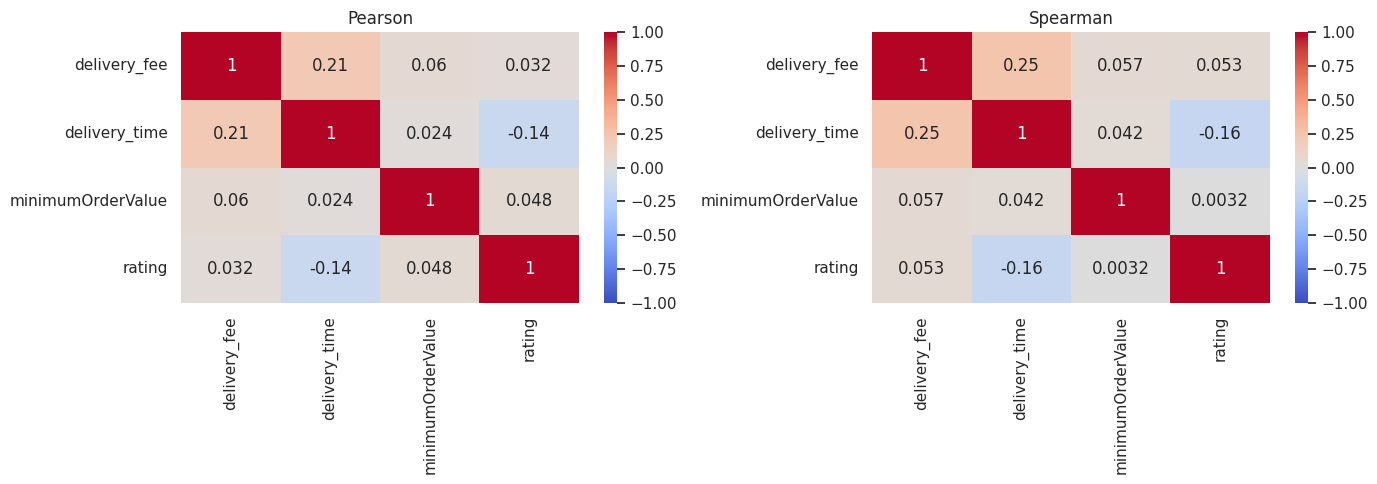

In [7]:
corr_p = df[col_num].corr(method='pearson')
corr_s = df[col_num].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_s, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman')
plt.tight_layout()
plt.show()

## 3. Histogramas

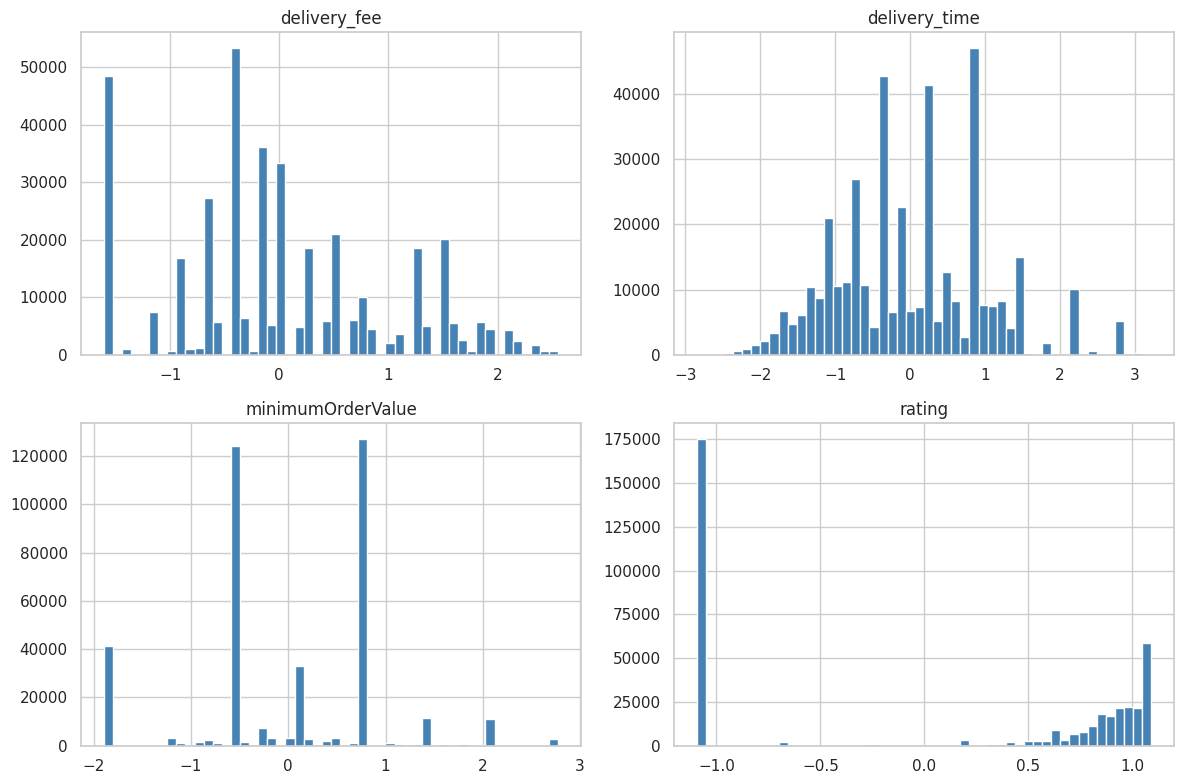

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), col_num):
    ax.hist(df[col], bins=50, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Boxplots

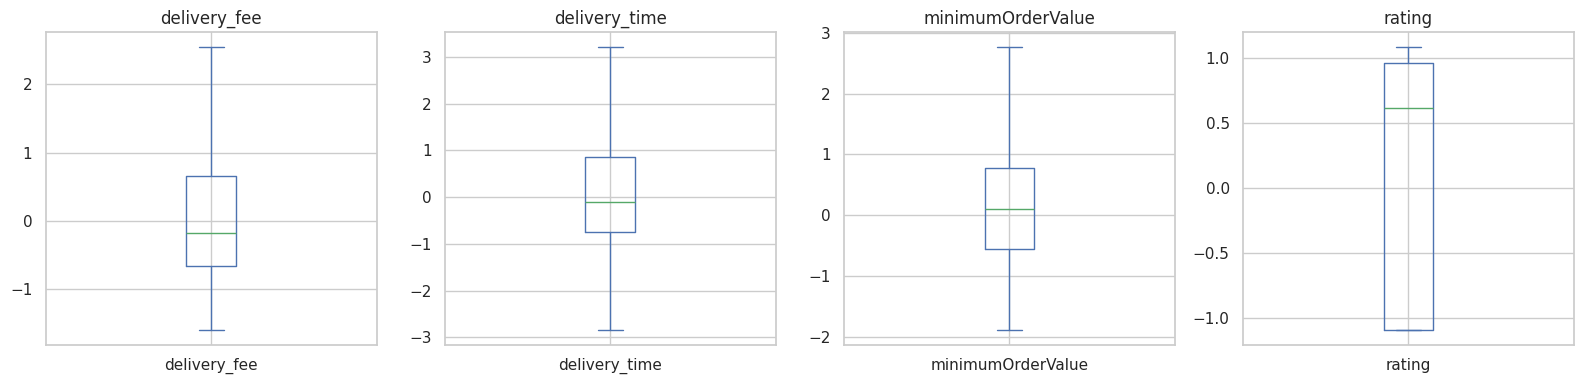

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, col_num):
    df[col].plot.box(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

As correlações entre as variáveis numéricas são fracas (todas abaixo de 0,3). A mais forte é entre `delivery_fee` e `delivery_time` (positiva, ~0,2), e `delivery_time` tem uma leve correlação negativa com `rating`. Como Pearson e Spearman ficam próximos, as relações são praticamente lineares. No geral há pouca redundância entre as variáveis. Os histogramas e boxplots mostram as distribuições já padronizadas, com alguns valores extremos mesmo após a limpeza da Etapa 1. Nos próximos pontos da Etapa 2 vamos tratar a redução de redundância e a análise de componentes (PCA).

# PCA - Variância explicada e projeção 2D

Vamos usar o PCA para cumprir dois objetivos: medir a variância e transformar os dados em 2D

In [11]:
from sklearn.decomposition import PCA
import numpy as np

X = df[col_num].values
pca = PCA()
pca.fit(X)

evr = pca.explained_variance_ratio_
acum = np.cumsum(evr)

tab_var = pd.DataFrame(
    {'variancia_explicada': evr, 'acumulada': acum},
    index=[f'PC{i}' for i in range(1, len(evr) + 1)]
)
tab_var.round(3)

,variancia_explicada,acumulada
PC1,0.311,0.311
PC2,0.271,0.582
PC3,0.235,0.817
PC4,0.183,1.000


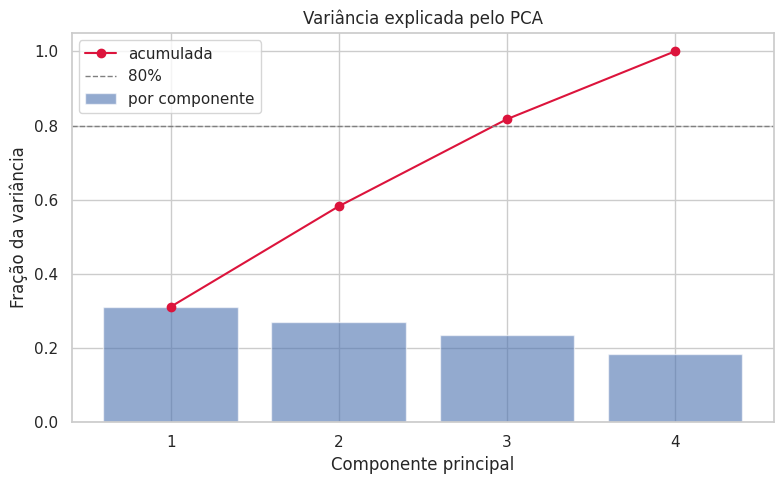

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
pcs = range(1, len(evr) + 1)
ax.bar(pcs, evr, alpha=0.6, label='por componente')
ax.plot(pcs, acum, 'o-', color='crimson', label='acumulada')
ax.axhline(0.8, ls='--', color='gray', lw=1, label='80%')
ax.set_xticks(list(pcs))
ax.set_xlabel('Componente principal')
ax.set_ylabel('Fração da variância')
ax.set_title('Variância explicada pelo PCA')
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra que a variância está bastante distribuída entre as quatro componentes (31%, 27%, 24% e 18%), sem nenhuma se destacar. Juntas, PC1 e PC2 explicam cerca de 58% da informação, e só a partir da PC3 chegamos aos 80%. Isso indica que o PCA praticamente não comprime estes dados. Já esperavamos esse resultado, dado que as variáveis apresentaram correlações fracas na análise anterior. Como não há redundância para o PCA explorar, cada componente carrega informação própria.

## Do que é feito cada componente?

In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=col_num,
    columns=[f'PC{i}' for i in range(1, len(evr) + 1)]
)
loadings.round(3)

,PC1,PC2,PC3,PC4
delivery_fee,0.622,0.329,-0.391,-0.594
delivery_time,0.712,-0.147,-0.033,0.686
minimumOrderValue,0.167,0.602,0.781,-0.006
rating,-0.281,0.713,-0.486,0.421


Podemos ver que nenhum componente é dominado exclusivamente por uma única variável.

## Gráfico plotável em  2D

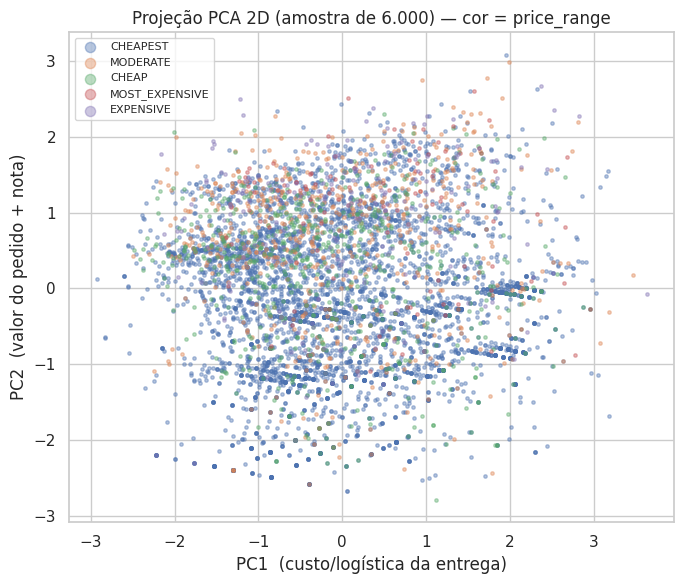

In [14]:
proj = pca.transform(X)[:, :2]

rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=6000, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
for faixa in df['price_range'].unique():
    m = df['price_range'].values[idx] == faixa
    ax.scatter(proj[idx][m, 0], proj[idx][m, 1], s=6, alpha=0.4, label=faixa)
ax.set_xlabel('PC1  (custo/logística da entrega)')
ax.set_ylabel('PC2  (valor do pedido + nota)')
ax.set_title('Projeção PCA 2D (amostra de 6.000) — cor = price_range')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

Cada ponto representa um restaurante, posicionado pelas suas coordenadas em PC1 e PC2, com a cor indicando a faixa de preço. Os pontos formam uma nuvem única, sem grupos bem definidos, e as faixas de preço aparecem misturadas pelo gráfico. Isso é coerente com a baixa correlação entre as variáveis e com a variância distribuída entre as componentes: o PCA não encontra uma separação clara nos dados. Vale lembrar que essa projeção usa apenas PC1 e PC2, ou seja, cerca de 58% da informação total.